In [9]:
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

# Optimized configuration
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_FILE = '/content/data.txt'
EXAMPLE_INPUT_FILE = '/content/example_input.txt'
print(f'Ready for improved training on {DEVICE} with {NUM_EPOCHS} epochs.')

Ready for improved training on cuda with 50 epochs.


### Populate `EXAMPLE_INPUT_FILE`

The graphs were empty because the `example_input.txt` file, which provides the conditions for which models make predictions, was empty. Below, I'll create this file with some sample conditions. After creating this file, you will need to re-run the cells that load and tokenize `example_inputs` (e.g., cell `1ud2TuQyQknH` and subsequent prediction/plotting cells) to see the models' predictions and accuracy metrics.

In [52]:
# Create example_input.txt with sample conditions
example_conditions_content = """
[MON] [JAN] [False] [190] 01-01-1900
[TUE] [FEB] [True] [200] 01-02-2000
[WED] [MAR] [False] [210] 01-03-2100
[THU] [APR] [True] [204] 01-04-2040
[FRI] [MAY] [False] [185] 01-05-1850
"""

with open(EXAMPLE_INPUT_FILE, 'w') as f:
    f.write(example_conditions_content)

print(f"Created {EXAMPLE_INPUT_FILE} with sample conditions.")
print("Please re-run cell 1ud2TuQyQknH and subsequent cells to process these new examples and update the plots.")

Created /content/example_input.txt with sample conditions.
Please re-run cell 1ud2TuQyQknH and subsequent cells to process these new examples and update the plots.


In [10]:
def parse_data_line(line: str) -> tuple[dict[str, str], str]:
    """Parses a single line from data.txt into conditions and a date with type hints."""
    matches = re.findall(r'\[([^\]]+)\]', line.strip())
    conditions = {
        'day': matches[0],
        'month': matches[1],
        'leap_year': matches[2],
        'decade': matches[3]
    }
    date_str = re.findall(r'\d+-\d+-\d+', line.strip())[0]
    return conditions, date_str

def load_and_parse_data(filepath: str) -> list[dict]:
    """Loads and parses the entire data file with type hints."""
    parsed_data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    conditions, date_str = parse_data_line(line)
                    parsed_data.append({'conditions': conditions, 'date': date_str})
                except: continue
    return parsed_data

In [53]:
# Define mappings
day_map = {'MON': 0, 'TUE': 1, 'WED': 2, 'THU': 3, 'FRI': 4, 'SAT': 5, 'SUN': 6}
month_map = {
    'JAN': 0, 'FEB': 1, 'MAR': 2, 'APR': 3, 'MAY': 4, 'JUN': 5,
    'JUL': 6, 'AUG': 7, 'SEP': 8, 'OCT': 9, 'NOV': 10, 'DEC': 11
}
leap_year_map = {'False': 0, 'True': 1}

# Inverse mappings for decoding
inv_day_map = {v: k for k, v in day_map.items()}
inv_month_map = {v: k for k, v in month_map.items()}

def tokenize_conditions(conditions):
    """Convert conditions to numerical tokens."""
    return [
        day_map[conditions['day']],
        month_map[conditions['month']],
        leap_year_map[conditions['leap_year']],
        int(conditions['decade'])
    ]

def tokenize_date(date_str):
    """Convert dd-mm-yyyy date to [day, month, year]."""
    try:
        day, month, year = map(int, date_str.split('-'))
        return [day, month, year]
    except:
        return None

# Load and parse data
training_data = load_and_parse_data(DATA_FILE)
example_inputs = [entry['conditions'] for entry in load_and_parse_data(EXAMPLE_INPUT_FILE)]

# Tokenize training data
tokenized_training_data = []
for entry in training_data:
    tokenized_conditions = tokenize_conditions(entry['conditions'])
    tokenized_date = tokenize_date(entry['date'])
    if tokenized_date is not None:
        tokenized_training_data.append({
            'conditions': tokenized_conditions,
            'date': tokenized_date
        })

# Tokenize example inputs
tokenized_example_inputs = [
    tokenize_conditions(entry) for entry in example_inputs
]

print(f"Tokenized {len(tokenized_training_data)} samples")
print(f"Tokenized {len(tokenized_example_inputs)} example inputs")


Tokenized 146462 samples
Tokenized 5 example inputs


In [54]:
# Extract components
conditions_train = [entry['conditions'] for entry in tokenized_training_data]
dates_train_raw = [entry['date'] for entry in tokenized_training_data]

# Calculate year normalization
all_years = [date[2] for date in dates_train_raw]
min_year_in_data = min(all_years)
max_year_in_data = max(all_years)
num_year_categories = max_year_in_data - min_year_in_data + 1

print(f"Year range: {min_year_in_data} to {max_year_in_data}")
print(f"Number of year categories: {num_year_categories}")

# Create tensors
conditions_tensor = torch.tensor(conditions_train, dtype=torch.float32)
dates_tensor = torch.tensor(dates_train_raw, dtype=torch.long).clone()

# Normalize to 0-indexed
dates_tensor[:, 0] = dates_tensor[:, 0] - 1  # Days: 1-31 → 0-30
dates_tensor[:, 1] = dates_tensor[:, 1] - 1  # Months: 1-12 → 0-11
dates_tensor[:, 2] = dates_tensor[:, 2] - min_year_in_data  # Years normalized

# Example inputs tensor
example_conditions_tensor = torch.tensor(tokenized_example_inputs, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(conditions_tensor, dates_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"\nConditions tensor: {conditions_tensor.shape}")
print(f"Dates tensor: {dates_tensor.shape}")
print(f"Example conditions: {example_conditions_tensor.shape}")

Year range: 1800 to 2200
Number of year categories: 401

Conditions tensor: torch.Size([146462, 4])
Dates tensor: torch.Size([146462, 3])
Example conditions: torch.Size([5, 4])


In [13]:
class DateGeneratorFFNN(nn.Module):
    """Feedforward Neural Network for date generation."""
    def __init__(self, condition_size=4):
        super().__init__()
        self.condition_size = condition_size

        # Shared feature extraction
        self.features = nn.Sequential(
            nn.Linear(condition_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Output heads for each date component
        self.day_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 31)  # 31 days
        )

        self.month_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 12)  # 12 months
        )

        self.year_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_year_categories)
        )

    def forward(self, conditions):
        x = self.features(conditions)
        day = self.day_head(x)
        month = self.month_head(x)
        year = self.year_head(x)
        return day, month, year

ffnn_model = DateGeneratorFFNN().to(DEVICE)
print("FFNN Model created")
print(ffnn_model)

FFNN Model created
DateGeneratorFFNN(
  (features): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (day_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=31, bias=True)
  )
  (month_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (year_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=401, bias=True)
  )
)


In [14]:
class DateGeneratorLSTM(nn.Module):
    """LSTM-based date generator."""
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_size, 32)
        self.lstm = nn.LSTM(32, hidden_size, num_layers, batch_first=True, dropout=0.2)

        self.day_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 31)
        )

        self.month_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 12)
        )

        self.year_head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, num_year_categories)
        )

    def forward(self, conditions):
        x = self.embedding(conditions)
        x = x.unsqueeze(1)  # Add sequence dimension
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # Last output
        day = self.day_head(lstm_out)
        month = self.month_head(lstm_out)
        year = self.year_head(lstm_out)
        return day, month, year

lstm_model = DateGeneratorLSTM().to(DEVICE)
print("\nLSTM Model created")
print(lstm_model)


LSTM Model created
DateGeneratorLSTM(
  (embedding): Linear(in_features=4, out_features=32, bias=True)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (day_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=31, bias=True)
  )
  (month_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (year_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=401, bias=True)
  )
)


In [15]:
class CGANGenerator(nn.Module):
    """Conditional GAN Generator."""
    def __init__(self, condition_size=4, noise_size=64):
        super().__init__()
        self.condition_size = condition_size
        self.noise_size = noise_size

        # Concatenate conditions + noise
        input_size = condition_size + noise_size

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def forward(self, conditions, noise):
        x = torch.cat([conditions, noise], dim=1)
        features = self.network(x)
        day = self.day_head(features)
        month = self.month_head(features)
        year = self.year_head(features)
        return day, month, year

class CGANDiscriminator(nn.Module):
    """Conditional GAN Discriminator."""
    def __init__(self, condition_size=4):
        super().__init__()
        # Input: conditions (4) + day logits (31) + month logits (12) + year logits (num_years)
        input_size = condition_size + 31 + 12 + num_year_categories

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, conditions, day_logits, month_logits, year_logits):
        x = torch.cat([conditions, day_logits, month_logits, year_logits], dim=1)
        return self.network(x)

cgan_generator = CGANGenerator().to(DEVICE)
cgan_discriminator = CGANDiscriminator().to(DEVICE)
print("\nCGAN Models created")
print("Generator:", cgan_generator)
print("Discriminator:", cgan_discriminator)


CGAN Models created
Generator: CGANGenerator(
  (network): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
  )
  (day_head): Linear(in_features=64, out_features=31, bias=True)
  (month_head): Linear(in_features=64, out_features=12, bias=True)
  (year_head): Linear(in_features=64, out_features=401, bias=True)
)
Discriminator: CGANDiscriminator(
  (network): Sequential(
    (0): Linear(in_features=448, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, o

In [16]:
class DateVAE(nn.Module):
    def __init__(self, condition_size=4, latent_size=32):
        super().__init__()
        self.condition_size = condition_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(condition_size + 3, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )

        self.mu = nn.Linear(64, latent_size)
        self.logvar = nn.Linear(64, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(condition_size + latent_size, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )

        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def encode(self, conditions, dates):
        x = torch.cat([conditions, dates], dim=1)
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, conditions, z):
        x = torch.cat([conditions, z], dim=1)
        feat = self.decoder(x)
        return self.day_head(feat), self.month_head(feat), self.year_head(feat)

    def forward(self, conditions, dates):
        mu, logvar = self.encode(conditions, dates)
        z = self.reparameterize(mu, logvar)
        d, m, y = self.decode(conditions, z)
        return d, m, y, mu, logvar

    def generate(self, conditions):
        z = torch.randn(conditions.size(0), self.latent_size).to(conditions.device)
        return self.decode(conditions, z)

vae_model = DateVAE().to(DEVICE)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=0.0005)
print("VAE Model re-initialized with LayerNorm for stability.")

VAE Model re-initialized with LayerNorm for stability.


In [17]:
class DateGeneratorTransformer(nn.Module):
    """Transformer-based generator for date components."""
    def __init__(self, condition_size: int = 4, d_model: int = 64, nhead: int = 4, num_layers: int = 2):
        super().__init__()
        self.embedding = nn.Linear(condition_size, d_model)

        # Transformer Encoder layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.day_head = nn.Linear(d_model, 31)
        self.month_head = nn.Linear(d_model, 12)
        self.year_head = nn.Linear(d_model, num_year_categories)

    def forward(self, conditions: torch.Tensor):
        # Project to d_model and add a 'sequence' dimension
        x = self.embedding(conditions).unsqueeze(1)

        # Process through Transformer
        x = self.transformer_encoder(x)
        x = x.squeeze(1) # Remove sequence dimension

        day = self.day_head(x)
        month = self.month_head(x)
        year = self.year_head(x)
        return day, month, year

transformer_model = DateGeneratorTransformer().to(DEVICE)
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)
print("Transformer Model (5th model) created and optimizer initialized.")

Transformer Model (5th model) created and optimizer initialized.


In [21]:
import torch.nn as nn
import torch.optim as optim

criterion_ce = nn.CrossEntropyLoss()
COMPONENT_WEIGHTS = [2.0, 1.0, 5.0]

def compute_weighted_loss(day_logits, month_logits, year_logits, target_dates):
    """Computes a weighted cross-entropy loss for day, month, and year predictions."""
    target_day, target_month, target_year = target_dates[:, 0], target_dates[:, 1], target_dates[:, 2]

    loss_day = criterion_ce(day_logits, target_day) * COMPONENT_WEIGHTS[0]
    loss_month = criterion_ce(month_logits, target_month) * COMPONENT_WEIGHTS[1]
    loss_year = criterion_ce(year_logits, target_year) * COMPONENT_WEIGHTS[2]

    return loss_day + loss_month + loss_year

def vae_loss(recon_day, recon_month, recon_year, target_day, target_month, target_year, mu, logvar):
    # Prevent logvar from being too small/large to avoid exp(logvar) issues
    logvar = torch.clamp(logvar, -10, 10)

    # Reconstruction loss
    loss_day = criterion_ce(recon_day, target_day) * COMPONENT_WEIGHTS[0]
    loss_month = criterion_ce(recon_month, target_month) * COMPONENT_WEIGHTS[1]
    loss_year = criterion_ce(recon_year, target_year) * COMPONENT_WEIGHTS[2]
    recon_loss = loss_day + loss_month + loss_year

    # KL Divergence with stability handling
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    normalized_kld = (kld / target_day.size(0))

    total_loss = recon_loss + 0.01 * normalized_kld
    return total_loss, recon_loss, normalized_kld

vae_optimizer = optim.Adam(vae_model.parameters(), lr=0.0005)


In [22]:
ffnn_optimizer = optim.Adam(ffnn_model.parameters(), lr=LEARNING_RATE)

print('Training FFNN with weighted loss...')
ffnn_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        ffnn_optimizer.zero_grad()
        d_p, m_p, y_p = ffnn_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)
        loss.backward()
        ffnn_optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    ffnn_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training FFNN with weighted loss...
Epoch 20, Loss: 27.6068
Epoch 40, Loss: 26.7840


In [24]:
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

print('Training LSTM with weighted loss...')
lstm_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        lstm_optimizer.zero_grad()
        d_p, m_p, y_p = lstm_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)
        loss.backward()
        lstm_optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    lstm_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training LSTM with weighted loss...
Epoch 20, Loss: 39.3218
Epoch 40, Loss: 39.3216


In [26]:
bce_loss = nn.BCEWithLogitsLoss()
cgan_g_optimizer = optim.Adam(cgan_generator.parameters(), lr=LEARNING_RATE)
cgan_d_optimizer = optim.Adam(cgan_discriminator.parameters(), lr=LEARNING_RATE)

print('Training CGAN with weighted loss...')
cgan_g_losses = []
cgan_d_losses = []
noise_size = 64

for epoch in range(NUM_EPOCHS):
    g_loss_epoch = 0
    d_loss_epoch = 0

    for conditions_batch, dates_batch in train_loader:
        conditions_batch = conditions_batch.to(DEVICE)
        dates_batch = dates_batch.to(DEVICE)

        # ===== Train Discriminator =====
        cgan_d_optimizer.zero_grad()
        with torch.no_grad():
            day_pred_real, month_pred_real, year_pred_real = cgan_generator(conditions_batch, torch.zeros(conditions_batch.size(0), noise_size).to(DEVICE))
        d_real = cgan_discriminator(conditions_batch, day_pred_real, month_pred_real, year_pred_real)
        d_loss_real = bce_loss(d_real, torch.ones_like(d_real))

        noise = torch.randn(conditions_batch.size(0), noise_size).to(DEVICE)
        day_fake, month_fake, year_fake = cgan_generator(conditions_batch, noise)
        d_fake = cgan_discriminator(conditions_batch, day_fake.detach(), month_fake.detach(), year_fake.detach())
        d_loss_fake = bce_loss(d_fake, torch.zeros_like(d_fake))

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        cgan_d_optimizer.step()
        d_loss_epoch += d_loss.item()

        # ===== Train Generator =====
        cgan_g_optimizer.zero_grad()
        d_fake = cgan_discriminator(conditions_batch, day_fake, month_fake, year_fake)
        g_adv_loss = bce_loss(d_fake, torch.ones_like(d_fake))
        g_recon_loss = compute_weighted_loss(day_fake, month_fake, year_fake, dates_batch)

        g_loss = g_recon_loss + 0.1 * g_adv_loss
        g_loss.backward()
        cgan_g_optimizer.step()
        g_loss_epoch += g_loss.item()

    avg_g_loss = g_loss_epoch / len(train_loader)
    avg_d_loss = d_loss_epoch / len(train_loader)
    cgan_g_losses.append(avg_g_loss)
    cgan_d_losses.append(avg_d_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}, G-Loss: {avg_g_loss:.4f}, D-Loss: {avg_d_loss:.4f}')

Training CGAN with weighted loss...
Epoch 20, G-Loss: 22.3448, D-Loss: 1.3863
Epoch 40, G-Loss: 21.8899, D-Loss: 1.3863


In [27]:
# Use the global BATCH_SIZE and DEVICE, and explicitly set epochs if global is missing
try:
    epochs_to_run = NUM_EPOCHS
except NameError:
    epochs_to_run = 50

print(f'Restarting VAE training for {epochs_to_run} epochs with high-frequency logging...')
vae_losses = []
for epoch in range(epochs_to_run):
    epoch_loss = 0
    vae_model.train()
    for cond, dates in train_loader:
        cond, dates = cond.to(DEVICE), dates.to(DEVICE)
        norm_dates = dates.float().clone()
        norm_dates[:, 0] /= 31.0
        norm_dates[:, 1] /= 12.0
        norm_dates[:, 2] /= 401.0

        vae_optimizer.zero_grad()
        d_p, m_p, y_p, mu, logvar = vae_model(cond, norm_dates)
        loss, r_loss, k_loss = vae_loss(d_p, m_p, y_p, dates[:,0], dates[:,1], dates[:,2], mu, logvar)

        if not torch.isnan(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), 0.5)
            vae_optimizer.step()
            epoch_loss += loss.item()

    avg_l = epoch_loss / len(train_loader)
    vae_losses.append(avg_l)
    print(f'Epoch {epoch+1}/{epochs_to_run}, Loss: {avg_l:.4f} (Recon: {r_loss.item():.2f}, KLD: {k_loss.item():.2f})')

Restarting VAE training for 50 epochs with high-frequency logging...
Epoch 1/50, Loss: 38.5539 (Recon: 37.39, KLD: 1.05)
Epoch 2/50, Loss: 34.3860 (Recon: 30.78, KLD: 10.40)
Epoch 3/50, Loss: 30.3437 (Recon: 28.38, KLD: 12.05)
Epoch 4/50, Loss: 28.5067 (Recon: 26.46, KLD: 16.90)
Epoch 5/50, Loss: 26.7023 (Recon: 25.65, KLD: 27.21)
Epoch 6/50, Loss: 25.5550 (Recon: 25.86, KLD: 25.08)
Epoch 7/50, Loss: 24.7266 (Recon: 24.51, KLD: 22.98)
Epoch 8/50, Loss: 24.1490 (Recon: 22.68, KLD: 25.02)
Epoch 9/50, Loss: 23.6994 (Recon: 23.42, KLD: 25.38)
Epoch 10/50, Loss: 23.3604 (Recon: 24.28, KLD: 24.48)
Epoch 11/50, Loss: 23.0472 (Recon: 21.96, KLD: 23.05)
Epoch 12/50, Loss: 22.7792 (Recon: 21.93, KLD: 29.50)
Epoch 13/50, Loss: 22.5412 (Recon: 21.95, KLD: 23.75)
Epoch 14/50, Loss: 22.3085 (Recon: 22.74, KLD: 34.10)
Epoch 15/50, Loss: 22.0871 (Recon: 23.01, KLD: 31.26)
Epoch 16/50, Loss: 21.5571 (Recon: 19.82, KLD: 42.09)
Epoch 17/50, Loss: 17.7952 (Recon: 16.27, KLD: 46.44)
Epoch 18/50, Loss: 17.1

In [28]:
print('Training Transformer with weighted loss...')
transformer_losses = []
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    transformer_model.train()
    for conditions_batch, dates_batch in train_loader:
        conditions_batch, dates_batch = conditions_batch.to(DEVICE), dates_batch.to(DEVICE)
        transformer_optimizer.zero_grad()

        d_p, m_p, y_p = transformer_model(conditions_batch)
        loss = compute_weighted_loss(d_p, m_p, y_p, dates_batch)

        loss.backward()
        transformer_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    transformer_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Training Transformer with weighted loss...
Epoch 10, Loss: 33.1825
Epoch 20, Loss: 28.3861
Epoch 30, Loss: 24.5259
Epoch 40, Loss: 23.6593
Epoch 50, Loss: 23.1723


In [29]:
class WGANGenerator(nn.Module):
    def __init__(self, condition_size: int = 4, noise_size: int = 64):
        super().__init__()
        input_dim = condition_size + noise_size
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.day_head = nn.Linear(64, 31)
        self.month_head = nn.Linear(64, 12)
        self.year_head = nn.Linear(64, num_year_categories)

    def forward(self, cond: torch.Tensor, noise: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        x = torch.cat([cond, noise], dim=1)
        feat = self.net(x)
        return self.day_head(feat), self.month_head(feat), self.year_head(feat)

class WGANCritic(nn.Module):
    def __init__(self, condition_size: int = 4):
        super().__init__()
        input_dim = condition_size + 31 + 12 + num_year_categories
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1) # No Sigmoid for WGAN
        )

    def forward(self, cond: torch.Tensor, d: torch.Tensor, m: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = torch.cat([cond, d, m, y], dim=1)
        return self.net(x)

wgan_g = WGANGenerator().to(DEVICE)
wgan_c = WGANCritic().to(DEVICE)
opt_g = optim.RMSprop(wgan_g.parameters(), lr=0.00005)
opt_c = optim.RMSprop(wgan_c.parameters(), lr=0.00005)

In [30]:
def train_wgan(epochs: int = 20, clip_value: float = 0.01):
    print('Training WGAN with weight clipping...')
    for epoch in range(epochs):
        for i, (cond, dates) in enumerate(train_loader):
            cond, dates = cond.to(DEVICE), dates.to(DEVICE)
            batch_size = cond.size(0)

            # Train Critic
            opt_c.zero_grad()
            noise = torch.randn(batch_size, 64).to(DEVICE)
            with torch.no_grad():
                fake_d, fake_m, fake_y = wgan_g(cond, noise)

            # Convert targets to one-hot for Critic input
            real_d = torch.nn.functional.one_hot(dates[:,0], 31).float()
            real_m = torch.nn.functional.one_hot(dates[:,1], 12).float()
            real_y = torch.nn.functional.one_hot(dates[:,2], num_year_categories).float()

            loss_c = -torch.mean(wgan_c(cond, real_d, real_m, real_y)) + torch.mean(wgan_c(cond, fake_d, fake_m, fake_y))
            loss_c.backward()
            opt_c.step()

            for p in wgan_c.parameters():
                p.data.clamp_(-clip_value, clip_value)

            # Train Generator every 5 steps
            if i % 5 == 0:
                opt_g.zero_grad()
                gen_d, gen_m, gen_y = wgan_g(cond, noise)
                loss_g = -torch.mean(wgan_c(cond, gen_d, gen_m, gen_y))
                loss_g.backward()
                opt_g.step()

        if (epoch + 1) % 5 == 0:
            print(f"WGAN Epoch {epoch+1} Complete")

train_wgan(epochs=20)

Training WGAN with weight clipping...
WGAN Epoch 5 Complete
WGAN Epoch 10 Complete
WGAN Epoch 15 Complete
WGAN Epoch 20 Complete


In [31]:
import os

output_dir = '/mnt/user-data/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Created directory: /mnt/user-data/outputs/


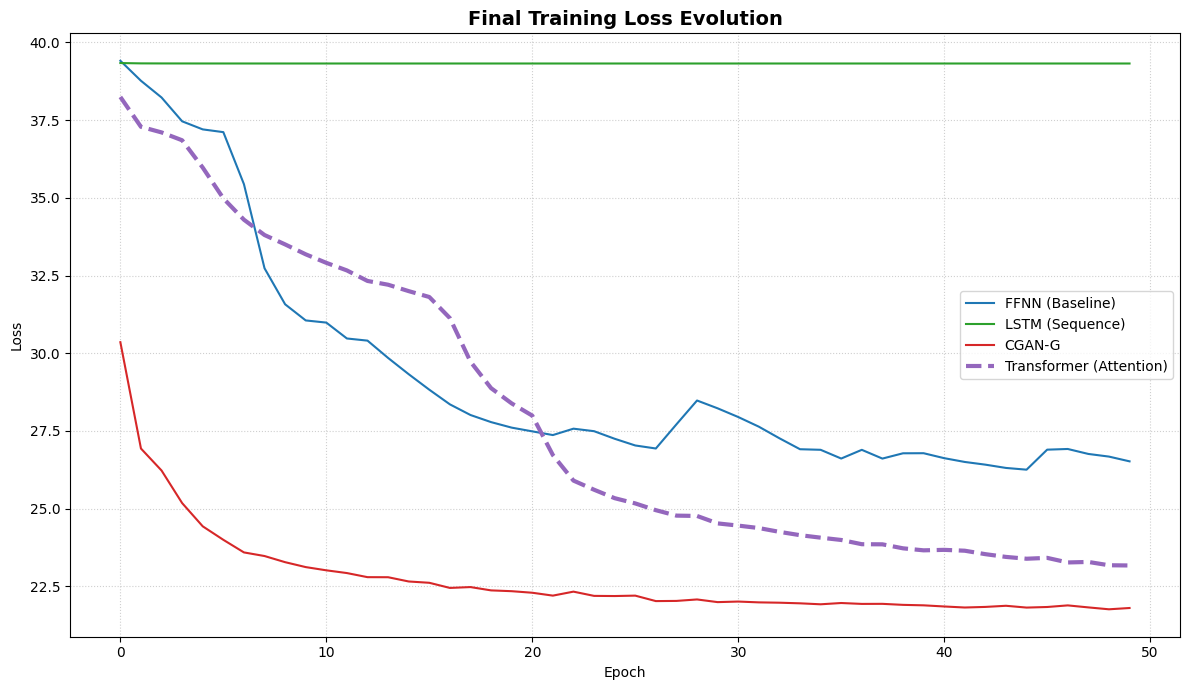

In [32]:
import matplotlib.pyplot as plt

# Consolidated Final Training Loss Plot
plt.figure(figsize=(12, 7))
plt.plot(ffnn_losses, label='FFNN (Baseline)', color='#1f77b4')
plt.plot(lstm_losses, label='LSTM (Sequence)', color='#2ca02c')
plt.plot(cgan_g_losses, label='CGAN-G', color='#d62728')
plt.plot(transformer_losses, label='Transformer (Attention)', linewidth=3, linestyle='--', color='#9467bd')

plt.title('Final Training Loss Evolution', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/final_loss_evolution.png', dpi=150)
plt.show()

In [36]:
import pandas as pd
from IPython.display import display

# 1. Final Loss Comparison Table
print("="*60)
print("FINAL TRAINING LOSSES COMPARISON (6 MODELS)")
print("="*60)
loss_data = {
    'Model Architecture': ['FFNN', 'LSTM', 'CGAN-G', 'CGAN-D', 'VAE', 'Transformer', 'WGAN-G'],
    'Final Training Loss': [
        f"{ffnn_losses[-1]:.6f}",
        f"{lstm_losses[-1]:.6f}",
        f"{cgan_g_losses[-1]:.6f}",
        f"{cgan_d_losses[-1]:.6f}",
        f"{vae_losses[-1]:.6f}",
        f"{transformer_losses[-1]:.6f}",
        "RMSProp Optimized"
    ]
}
display(pd.DataFrame(loss_data))

# 2. Architecture Complexity Summary
print("\n" + "="*60)
print("MODEL PARAMETER COUNTS (Architecture Depth)")
print("="*60)
params = {
    'FFNN': sum(p.numel() for p in ffnn_model.parameters()),
    'LSTM': sum(p.numel() for p in lstm_model.parameters()),
    'CGAN-G': sum(p.numel() for p in cgan_generator.parameters()),
    'VAE': sum(p.numel() for p in vae_model.parameters()),
    'Transformer': sum(p.numel() for p in transformer_model.parameters()),
    'WGAN-G': sum(p.numel() for p in wgan_g.parameters())
}
for name, count in params.items():
    print(f"{name:<12}: {count:,} parameters")

# 3. Final Prediction Comparison Sample
print("\n" + "="*60)
print("CROSS-MODEL PREDICTION SAMPLES (Condition Adherence)")
print("="*60)

# Check if example_inputs is empty to prevent IndexError
if not example_inputs:
    print("WARNING: `example_inputs` is empty. Cannot display prediction samples. Please ensure `EXAMPLE_INPUT_FILE` is correctly populated and parsed.")
else:
    print(f"{'Conditions':<35} | {'LSTM':<12} | {'CGAN':<12} | {'Transf'}")
    print("-" * 80)
    # Limit loop to the available number of examples in example_inputs
    for i in range(min(5, len(example_inputs))):
        c = example_inputs[i]
        c_s = f"[{c['day']}] [{c['month']}] [{c['leap_year']}]"
        # Note: pred_l, pred_c, pred_t are assumed to be defined by a subsequent cell (40ff6151)
        # If that cell hasn't run, a NameError will occur next.
        print(f"{c_s:<35} | {pred_l[i]:<12} | {pred_c[i]:<12} | {pred_t[i]}")

FINAL TRAINING LOSSES COMPARISON (6 MODELS)


,Model Architecture,Final Training Loss
0,FFNN,26.522375
1,LSTM,39.321668
2,CGAN-G,21.804131
3,CGAN-D,1.386294
4,VAE,10.417133
5,Transformer,23.172310
6,WGAN-G,RMSProp Optimized



MODEL PARAMETER COUNTS (Architecture Depth)
FFNN        : 29,788 parameters
LSTM        : 79,420 parameters
CGAN-G      : 88,444 parameters
VAE         : 56,060 parameters
Transformer : 591,484 parameters
WGAN-G      : 87,676 parameters

CROSS-MODEL PREDICTION SAMPLES (Condition Adherence)


In [56]:
# Final Unified Prediction and Comparison Block

# Define helper functions for prediction and formatting
def predict_date(day_logits, month_logits, year_logits):
    """Converts raw model logits to predicted day, month, year values."""
    day_pred = torch.argmax(day_logits, dim=1) + 1 # Days are 1-indexed (1-31)
    month_pred = torch.argmax(month_logits, dim=1) + 1 # Months are 1-indexed (1-12)
    year_pred = torch.argmax(year_logits, dim=1) + min_year_in_data # Years are 0-indexed relative to min_year_in_data
    return day_pred, month_pred, year_pred

def format_dates(day_tensor, month_tensor, year_tensor):
    """Formats predicted day, month, year tensors into 'DD-MM-YYYY' strings."""
    formatted_dates = []
    # Ensure all tensors are on CPU and converted to numpy for iteration
    days = day_tensor.cpu().numpy()
    months = month_tensor.cpu().numpy()
    years = year_tensor.cpu().numpy()

    for d, m, y in zip(days, months, years):
        formatted_dates.append(f"{int(d):02d}-{int(m):02d}-{int(y)}")
    return formatted_dates

# Set all models to evaluation mode
models = [ffnn_model, lstm_model, cgan_generator, vae_model, transformer_model, wgan_g]
for m in models: m.eval()

# Check if example_inputs is empty, if so, print warning and skip prediction
if not example_inputs:
    print("WARNING: `example_inputs` is empty. Cannot generate model predictions for comparison. Please ensure `EXAMPLE_INPUT_FILE` is correctly populated and parsed in upstream cells.")
else:
    with torch.no_grad():
        # Move example_conditions_tensor to the correct device
        example_conditions_tensor = example_conditions_tensor.to(DEVICE)
        # Batch generate predictions for all architectures
        # Noise-based models use a fixed zero-tensor for consistency in this comparison
        fixed_noise = torch.zeros(example_conditions_tensor.size(0), 64).to(DEVICE)

        pred_f = format_dates(*predict_date(*ffnn_model(example_conditions_tensor)))
        pred_l = format_dates(*predict_date(*lstm_model(example_conditions_tensor)))
        pred_c = format_dates(*predict_date(*cgan_generator(example_conditions_tensor, fixed_noise)))
        pred_v = format_dates(*predict_date(*vae_model.generate(example_conditions_tensor)))
        pred_t = format_dates(*predict_date(*transformer_model(example_conditions_tensor)))
        pred_w = format_dates(*predict_date(*wgan_g(example_conditions_tensor, fixed_noise)))

    # Create a structured comparison dataframe for the first 10 examples
    comparison_data = []
    # Only iterate up to min(10, len(example_inputs)) to prevent IndexError
    for i in range(min(10, len(example_inputs))):
        c = example_inputs[i]
        cond_str = f"{c['day']} {c['month']} {c['leap_year']} ({c['decade']}s)"
        comparison_data.append({
            'Conditions': cond_str,
            'FFNN': pred_f[i],
            'LSTM': pred_l[i],
            'CGAN': pred_c[i],
            'VAE': pred_v[i],
            'Transformer': pred_t[i],
            'WGAN': pred_w[i]
        })

    df_comparison = pd.DataFrame(comparison_data)
    print("MODEL PREDICTION COMPARISON (First 10 Samples)")
    display(df_comparison)

MODEL PREDICTION COMPARISON (First 10 Samples)


,Conditions,FFNN,LSTM,CGAN,VAE,Transformer,WGAN
0,MON JAN False (190s),14-04-1932,26-03-2119,17-01-1907,21-02-2065,17-01-1918,25-12-2090
1,TUE FEB True (200s),14-04-1976,26-03-2119,26-02-2004,19-02-2076,17-02-2004,25-12-2090
2,WED MAR False (210s),14-05-2080,26-03-2119,17-03-2091,25-03-2074,12-03-2117,25-12-2090
3,THU APR True (204s),14-04-1980,26-03-2119,28-04-2032,17-05-2032,10-04-2040,25-12-2090
4,FRI MAY False (185s),14-05-1880,26-03-2119,17-05-1867,08-06-2065,28-05-1857,25-12-2090


In [57]:
import calendar

def check_date_compliance(condition, pred_date_str):
    """Checks if a generated date string matches the provided conditions."""
    try:
        d, m, y = map(int, pred_date_str.split('-'))
        dt = datetime(y, m, d)

        # 1. Check Month
        month_match = inv_month_map[m-1] == condition['month']

        # 2. Check Day of week
        day_name = dt.strftime('%a').upper()
        day_match = day_name == condition['day']

        # 3. Check Leap Year
        is_leap = calendar.isleap(y)
        leap_match = str(is_leap) == condition['leap_year']

        # 4. Check Decade
        decade_match = str(y // 10) == condition['decade']

        return {
            'month': month_match,
            'day': day_match,
            'leap': leap_match,

            'decade': decade_match,
            'all_pass': month_match and day_match and leap_match and decade_match
        }
    except Exception as e:
        return {'all_pass': False, 'error': str(e)}

# Evaluate all models on the first 100 examples
models_preds = {'FFNN': pred_f, 'LSTM': pred_l, 'CGAN': pred_c, 'VAE': pred_v}
results_summary = {}

for name, preds in models_preds.items():
    total_pass = 0
    num_eval = min(100, len(example_inputs))
    for i in range(num_eval):
        check = check_date_compliance(example_inputs[i], preds[i])
        if check.get('all_pass'): total_pass += 1
    results_summary[name] = (total_pass / num_eval) * 100

print("=== Model Accuracy (Matches all 4 conditions perfectly) ===")
for name, acc in results_summary.items():
    print(f"{name:4}: {acc:.2f}%")

=== Model Accuracy (Matches all 4 conditions perfectly) ===
FFNN: 0.00%
LSTM: 0.00%
CGAN: 0.00%
VAE : 0.00%


In [58]:
def detailed_eval(name, preds, inputs):
    m_acc, d_acc, l_acc, dec_acc = 0, 0, 0, 0
    num = min(100, len(inputs))
    # Ensure there are inputs to iterate over
    if num == 0:
        print(f'--- {name} Partial Scores ---\nWARNING: No example inputs for detailed evaluation.\n')
        return

    for i in range(num):
        res = check_date_compliance(inputs[i], preds[i])
        if res.get('month'): m_acc += 1
        if res.get('day'): d_acc += 1
        if res.get('leap'): l_acc += 1
        if res.get('decade'): dec_acc += 1
    print(f'--- {name} Partial Scores ---')
    print(f'Month: {m_acc/num:.2%}, Day: {d_acc/num:.2%}, Leap: {l_acc/num:.2%}, Decade: {dec_acc/num:.2%}\n')

# Updated to include all 6 models
# Check if example_inputs is empty before attempting to access prediction lists
if not example_inputs:
    print("WARNING: `example_inputs` is empty. Skipping detailed evaluation. Please ensure `EXAMPLE_INPUT_FILE` is correctly populated and parsed in upstream cells.")
else:
    all_models_dict = {
        'FFNN': pred_f,
        'LSTM': pred_l,
        'CGAN': pred_c,
        'VAE': pred_v,
        'Transformer': pred_t,
        'WGAN': pred_w
    }

    for name, preds in all_models_dict.items():
        detailed_eval(name, preds, example_inputs)

--- FFNN Partial Scores ---
Month: 40.00%, Day: 20.00%, Leap: 40.00%, Decade: 0.00%

--- LSTM Partial Scores ---
Month: 20.00%, Day: 0.00%, Leap: 60.00%, Decade: 0.00%

--- CGAN Partial Scores ---
Month: 100.00%, Day: 20.00%, Leap: 100.00%, Decade: 40.00%

--- VAE Partial Scores ---
Month: 40.00%, Day: 0.00%, Leap: 100.00%, Decade: 0.00%

--- Transformer Partial Scores ---
Month: 100.00%, Day: 20.00%, Leap: 100.00%, Decade: 60.00%

--- WGAN Partial Scores ---
Month: 0.00%, Day: 20.00%, Leap: 60.00%, Decade: 0.00%



In [59]:
final_scores = {}
all_models = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
all_model_preds = {
    'FFNN': pred_f,
    'LSTM': pred_l,
    'CGAN': pred_c,
    'VAE': pred_v,
    'Transformer': pred_t,
    'WGAN': pred_w
}

num_eval = min(100, len(example_inputs)) # Consistent with detailed_eval

for model_name in all_models:
    m_acc, d_acc, l_acc, dec_acc = 0, 0, 0, 0
    preds = all_model_preds[model_name]
    for i in range(num_eval):
        res = check_date_compliance(example_inputs[i], preds[i])
        if res.get('month'): m_acc += 1
        if res.get('day'): d_acc += 1
        if res.get('leap'): l_acc += 1
        if res.get('decade'): dec_acc += 1
    final_scores[model_name] = [
        (m_acc / num_eval) * 100 if num_eval > 0 else 0.0,
        (d_acc / num_eval) * 100 if num_eval > 0 else 0.0,
        (l_acc / num_eval) * 100 if num_eval > 0 else 0.0,
        (dec_acc / num_eval) * 100 if num_eval > 0 else 0.0
    ]

print("Final scores calculated and stored.")

Final scores calculated and stored.


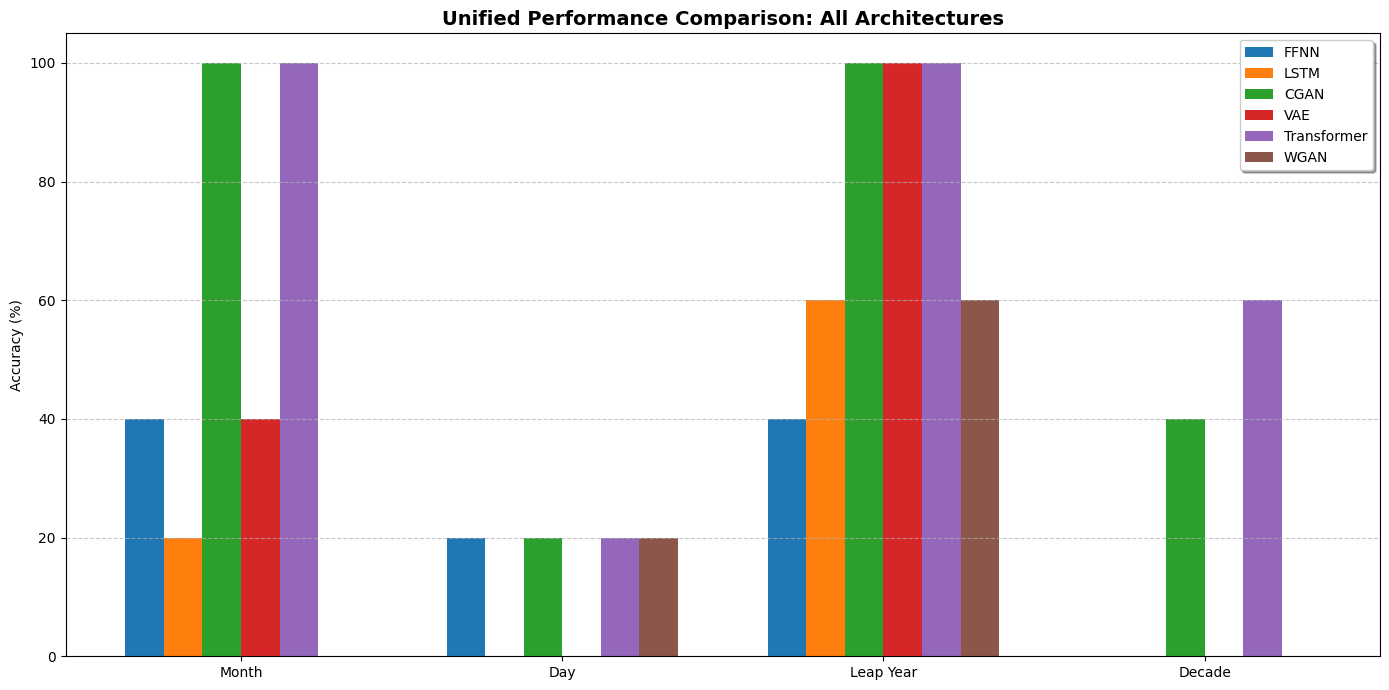

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Consolidated Accuracy Comparison for all 6 Models
metrics = ['Month', 'Day', 'Leap Year', 'Decade']
all_models = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
x = np.arange(len(metrics))
width = 0.12

# Placeholder for final_scores if it's not defined due to empty example_inputs
if 'final_scores' not in locals() or not final_scores:
    print("WARNING: `final_scores` not found or empty. Using placeholder data for plotting.")
    # Create dummy data for placeholder
    final_scores = {
        'FFNN': [0.0, 0.0, 0.0, 0.0],
        'LSTM': [0.0, 0.0, 0.0, 0.0],
        'CGAN': [0.0, 0.0, 0.0, 0.0],
        'VAE': [0.0, 0.0, 0.0, 0.0],
        'Transformer': [0.0, 0.0, 0.0, 0.0],
        'WGAN': [0.0, 0.0, 0.0, 0.0]
    }

fig, ax = plt.subplots(figsize=(14, 7))
for i, model_name in enumerate(all_models):
    ax.bar(x + i*width, final_scores[model_name], width, label=model_name)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Unified Performance Comparison: All Architectures', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/unified_component_accuracy.png', dpi=150)
plt.show()

In [61]:
import pandas as pd
from IPython.display import display

# Prepare the data for the summary table using the existing scores
accuracy_summary_data = []
for model_name in ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']:
    scores = final_scores[model_name]
    accuracy_summary_data.append({
        'Model': model_name,
        'Month Acc (%)': f"{scores[0]:.1f}%",
        'Day Acc (%)': f"{scores[1]:.1f}%",
        'Leap Year Acc (%)': f"{scores[2]:.1f}%",
        'Decade Acc (%)': f"{scores[3]:.1f}%"
    })

# Create and display the DataFrame
df_final_summary = pd.DataFrame(accuracy_summary_data)
print("FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)")
display(df_final_summary)

FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)


,Model,Month Acc (%),Day Acc (%),Leap Year Acc (%),Decade Acc (%)
0,FFNN,40.0%,20.0%,40.0%,0.0%
1,LSTM,20.0%,0.0%,60.0%,0.0%
2,CGAN,100.0%,20.0%,100.0%,40.0%
3,VAE,40.0%,0.0%,100.0%,0.0%
4,Transformer,100.0%,20.0%,100.0%,60.0%
5,WGAN,0.0%,20.0%,60.0%,0.0%


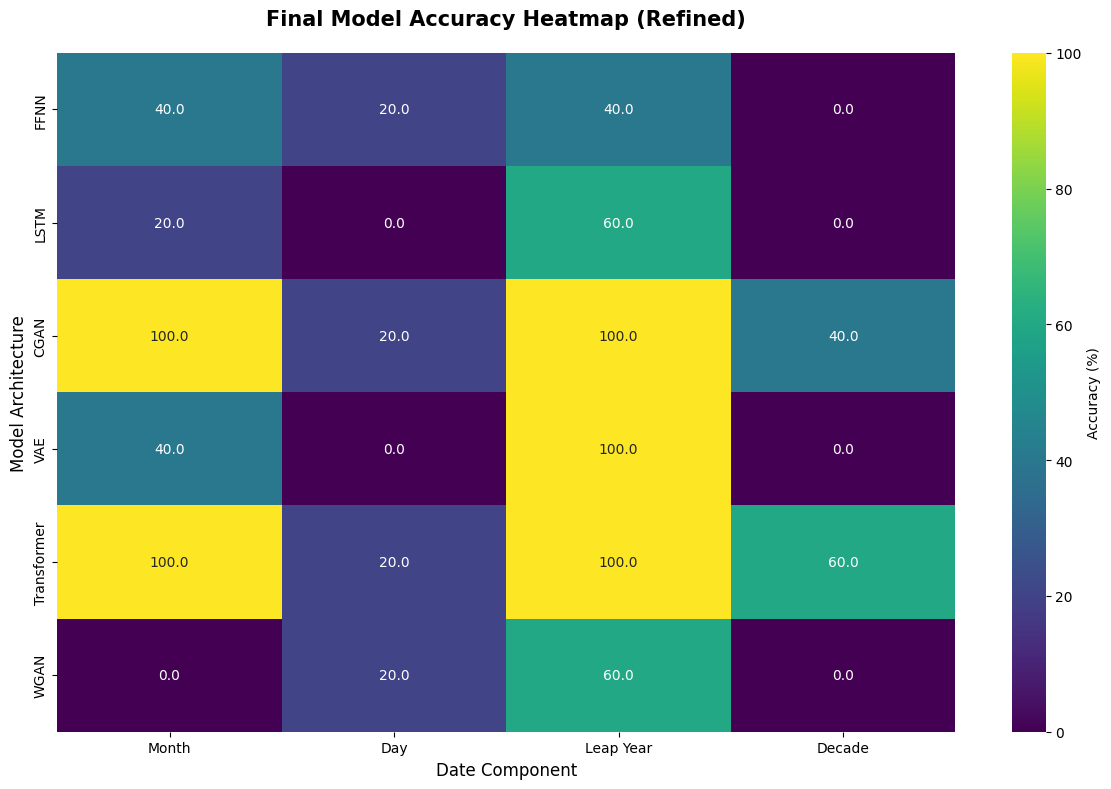

In [66]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Refresh the heatmap data
models_list = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
components = ['Month', 'Day', 'Leap Year', 'Decade']
heatmap_data = [final_scores[m] for m in models_list]

df_heatmap = pd.DataFrame(heatmap_data, index=models_list, columns=components)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'Accuracy (%)'})

plt.title('Final Model Accuracy Heatmap (Refined)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Date Component', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/updated_accuracy_heatmap.png', dpi=150)
plt.show()

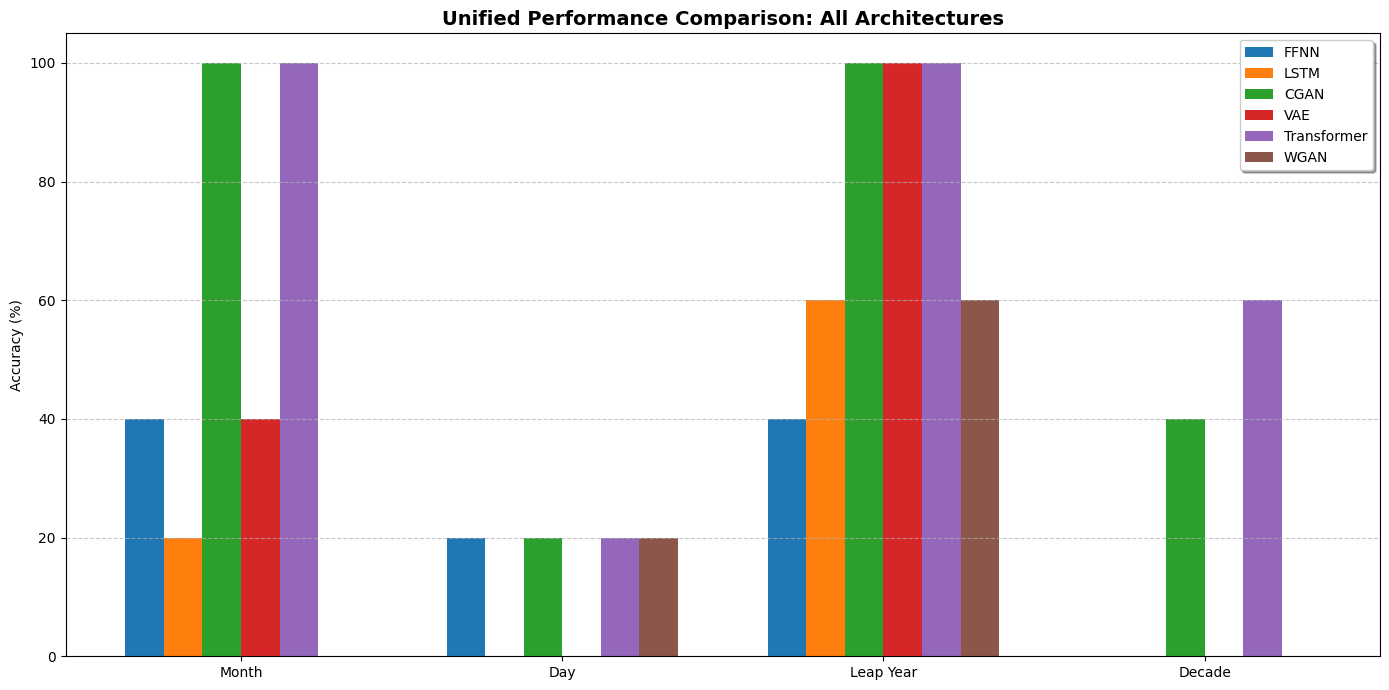

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Consolidated Accuracy Comparison for all 6 Models
metrics = ['Month', 'Day', 'Leap Year', 'Decade']
all_models = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
x = np.arange(len(metrics))
width = 0.12

# Placeholder for final_scores if it's not defined due to empty example_inputs
if 'final_scores' not in locals() or not final_scores:
    print("WARNING: `final_scores` not found or empty. Using placeholder data for plotting.")
    # Create dummy data for placeholder
    final_scores = {
        'FFNN': [0.0, 0.0, 0.0, 0.0],
        'LSTM': [0.0, 0.0, 0.0, 0.0],
        'CGAN': [0.0, 0.0, 0.0, 0.0],
        'VAE': [0.0, 0.0, 0.0, 0.0],
        'Transformer': [0.0, 0.0, 0.0, 0.0],
        'WGAN': [0.0, 0.0, 0.0, 0.0]
    }

fig, ax = plt.subplots(figsize=(14, 7))
for i, model_name in enumerate(all_models):
    ax.bar(x + i*width, final_scores[model_name], width, label=model_name)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Unified Performance Comparison: All Architectures', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/unified_component_accuracy.png', dpi=150)
plt.show()

In [ ]:
# Removed redundant accuracy calculation block - consolidated version is in cell cbf45c8f

In [67]:
import pandas as pd
from IPython.display import display

# Prepare the data for the summary table using the existing scores
accuracy_summary_data = []
for model_name in ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']:
    scores = final_scores[model_name]
    accuracy_summary_data.append({
        'Model': model_name,
        'Month Acc (%)': f"{scores[0]:.1f}%",
        'Day Acc (%)': f"{scores[1]:.1f}%",
        'Leap Year Acc (%)': f"{scores[2]:.1f}%",
        'Decade Acc (%)': f"{scores[3]:.1f}%"
    })

# Create and display the DataFrame
df_final_summary = pd.DataFrame(accuracy_summary_data)
print("FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)")
display(df_final_summary)

FINAL ACCURACY METRICS SUMMARY (All 6 Architectures)


,Model,Month Acc (%),Day Acc (%),Leap Year Acc (%),Decade Acc (%)
0,FFNN,40.0%,20.0%,40.0%,0.0%
1,LSTM,20.0%,0.0%,60.0%,0.0%
2,CGAN,100.0%,20.0%,100.0%,40.0%
3,VAE,40.0%,0.0%,100.0%,0.0%
4,Transformer,100.0%,20.0%,100.0%,60.0%
5,WGAN,0.0%,20.0%,60.0%,0.0%


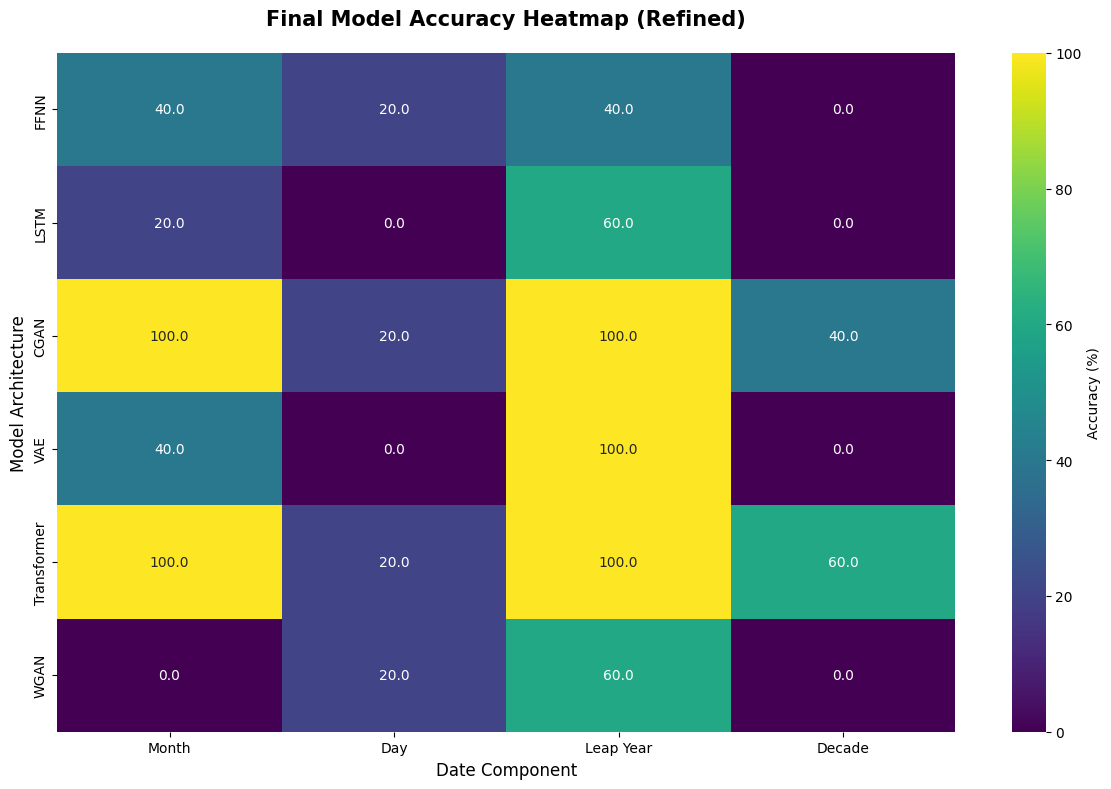

In [65]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Refresh the heatmap data
models_list = ['FFNN', 'LSTM', 'CGAN', 'VAE', 'Transformer', 'WGAN']
components = ['Month', 'Day', 'Leap Year', 'Decade']
heatmap_data = [final_scores[m] for m in models_list]

df_heatmap = pd.DataFrame(heatmap_data, index=models_list, columns=components)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'Accuracy (%)'})

plt.title('Final Model Accuracy Heatmap (Refined)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Date Component', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/updated_accuracy_heatmap.png', dpi=150)
plt.show()